Carrera en Laberinto con Aprendizaje por Refuerzo (AxR)

Asignación de Agente: Agente 1 - Carrera en Laberinto

Objetivo: Construir un agente inteligente que compita contra otro para llegar primero a la meta en un laberinto con obstáculos, descubriendo atajos y aprovechando rutas rápidas. Para el proceso de exploración/explotación de nuestro agente se aplicará la estrategia de "Selección de acciones con intervalo de confianza" (UCB - Upper Confidence Bound), comparándolo contra un agente competidor que utiliza la estrategia clásica de $\epsilon$-greedy.

---

Identificación y Explicación de los Elementos del Agente y del Entorno

Antes de iniciar con el código, identificamos y explicamos formalmente los componentes de nuestro sistema de Aprendizaje por Refuerzo, basándonos en la teoría estudiada en el segundo parcial:

1. Los Estados S:

   -El estado del agente está representado por su posición bidimensional en el laberinto, es decir, sus coordenadas de fila y columna: s = (fila, columna).

   -En un laberinto de tamaño 6X6, existen 36 estados posibles en total (menos los ocupados por las paredes u obstáculos).

2. El Entorno E:
   -Es un laberinto representado por una cuadrícula de 6X6.

   -Contiene una casilla de Inicio (Start) en (0, 0), una casilla de Meta en (5, 5), y una serie de paredes/obstáculos fijos en ciertas coordenadas donde los agentes no pueden transitar.
   
   -El entorno define las dinámicas físicas: si un agente intenta caminar hacia una pared o salirse de los límites, permanece en la misma casilla.

3. La Política ($\pi$):
   La política define el comportamiento del agente en cada estado.
   -Para el Agente 1 (Nuestro Agente - UCB): La política selecciona la acción $a$ en el estado $s$ que maximiza la estimación del valor sumada a un intervalo de confianza:
     $$ A_t = \underset{a}{\arg\max} \left[ Q(s, a) + c \sqrt{\frac{\ln N_t(s)}{N_t(s, a)}} \right] $$
     Donde $N_t(s)$ es el número de visitas al estado $s$, $N_t(s, a)$ es el número de veces que se tomó la acción $a$ en el estado $s$, y $c$ es la constante de exploración. Esto fuerza una exploración sistemática de caminos estrechos o poco transitados (atajos).
   
   -Para el Agente 2 (Competidor - $\epsilon$-greedy)**: Con probabilidad $\epsilon$ elige una acción completamente al azar (exploración aleatoria), y con probabilidad $1 - \epsilon$ explota el mejor valor actual de la tabla $Q(s, a)$.

4. La Recompensa R:
   -Es el valor numérico de retroalimentación que el entorno da al agente en cada paso:

     -Llegar a la Meta: +20 puntos (y termina la partida).

     -Paso normal: -1 punto (penalización para forzar al agente a buscar la ruta más rápida y corta).

     -Chocar contra una pared: -2 puntos (penalización por colisión para desincentivar movimientos inútiles).

5. La Función de Acción-Valor Q(s, a):
   -Representa la recompensa acumulada esperada a largo plazo al tomar la acción $a$ estando en el estado $s$.

   -Se almacena como una tabla (Q-table) indexada por pares `(estado, acción)`.

   -Se actualiza de forma incremental utilizando el algoritmo Q-learning.
   
     Donde $\alpha$ es el *learning rate* ($0.1$) y $\gamma$ es el factor de descuento ($0.95$).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from tqdm import tqdm

np.random.seed(42)
random.seed(42)


In [3]:
class Labyrinth:
    def __init__(self):
        self.size = 6
        self.start = (0, 0)
        self.goal = (5, 5)
        
        # Definimos obstáculos/paredes en el laberinto
        # Creamos una barrera vertical con una pequeña abertura ("Atajo") que requiere exploración para ser descuebierta
        self.walls = [
            (1, 2), (2, 2), (3, 2), (4, 2),  # Barrera en la columna 2
            (3, 4), (4, 4), (5, 4)           # Barrera inferior en la columna 4
        ]
        
        # Acciones: 0 = Arriba, 1 = Abajo, 2 = Izquierda, 3 = Derecha
        self.actions = [0, 1, 2, 3]
        self.action_effects = {
            0: (-1, 0),  # Arriba
            1: (1, 0),   # Abajo
            2: (0, -1),  # Izquierda
            3: (0, 1)    # Derecha
        }
        
    def is_valid_state(self, state):
        r, c = state
        if 0 <= r < self.size and 0 <= c < self.size:
            if state not in self.walls:
                return True
        return False
        
    def step(self, state, action):
        if state == self.goal:
            return state, 0, True
            
        effect = self.action_effects[action]
        next_state = (state[0] + effect[0], state[1] + effect[1])
        
        # Si el movimiento es inválido (fuera de límites o choca contra una pared)
        if not self.is_valid_state(next_state):
            return state, -2, False  # Penalización alta por chocar, permanece en el mismo estado
            
        # Si llega a la meta
        if next_state == self.goal:
            return next_state, 20, True
            
        # Paso normal (costo de tiempo)
        return next_state, -1, False
        
    def render(self, agent_pos_1=None, agent_pos_2=None):
        grid = np.chararray((self.size, self.size), itemsize=3, unicode=True)
        grid[:] = '. '
        
        for r, c in self.walls:
            grid[r, c] = '██'
            
        grid[self.start[0], self.start[1]] = 'S '
        grid[self.goal[0], self.goal[1]] = 'G '
        
        if agent_pos_1 is not None and agent_pos_2 is not None:
            if agent_pos_1 == agent_pos_2:
                grid[agent_pos_1[0], agent_pos_1[1]] = '12'
            else:
                grid[agent_pos_1[0], agent_pos_1[1]] = 'A1'
                grid[agent_pos_2[0], agent_pos_2[1]] = 'A2'
        elif agent_pos_1 is not None:
            grid[agent_pos_1[0], agent_pos_1[1]] = 'A1'
        elif agent_pos_2 is not None:
            grid[agent_pos_2[0], agent_pos_2[1]] = 'A2'
            
        print("\n  " + "-" * (self.size * 4 + 1))
        for r in range(self.size):
            row_str = " | "
            for c in range(self.size):
                row_str += grid[r, c] + " | "
            print(row_str)
            print("  " + "-" * (self.size * 4 + 1))


In [4]:
class UCBAgent:
    def __init__(self, alpha=0.1, gamma=0.95, c=1.0):
        self.alpha = alpha
        self.gamma = gamma
        self.c = c
        
        # Inicialización de la tabla Q y contadores
        self.Q = {}
        self.N_s = {}       # Visitas totales al estado s
        self.N_sa = {}      # Veces que se toma la acción a en el estado s
        
    def get_Q(self, state, action):
        if (state, action) not in self.Q:
            self.Q[(state, action)] = 0.0
        return self.Q[(state, action)]
        
    def get_N_s(self, state):
        if state not in self.N_s:
            self.N_s[state] = 0
        return self.N_s[state]
        
    def get_N_sa(self, state, action):
        if (state, action) not in self.N_sa:
            self.N_sa[(state, action)] = 0
        return self.N_sa[(state, action)]
        
    def choose_action(self, state, valid_actions, step):
        # Si estamos al inicio o no hemos visitado el estado
        n_s = self.get_N_s(state)
        
        best_action = None
        max_upper_bound = -1e9
        
        for action in valid_actions:
            n_sa = self.get_N_sa(state, action)
            
            # Si una acción no ha sido explorada nunca en este estado, le asignamos prioridad máxima
            if n_sa == 0:
                return action
                
            # Fórmula UCB
            q_val = self.get_Q(state, action)
            exploration_bonus = self.c * math.sqrt(math.log(n_s) / n_sa)
            upper_bound = q_val + exploration_bonus
            
            if upper_bound > max_upper_bound:
                max_upper_bound = upper_bound
                best_action = action
                
        return best_action
        
    def update(self, state, action, reward, next_state, next_valid_actions):
        # Incrementamos contadores de visitas
        self.N_s[state] = self.get_N_s(state) + 1
        self.N_sa[(state, action)] = self.get_N_sa(state, action) + 1
        
        # Máximo valor de Q en el siguiente estado
        max_next_q = 0.0
        if next_valid_actions:
            max_next_q = max([self.get_Q(next_state, a) for a in next_valid_actions])
            
        # Actualización Q-learning temporal-difference
        current_q = self.get_Q(state, action)
        self.Q[(state, action)] = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)


In [5]:
class EpsilonGreedyAgent:
    def __init__(self, alpha=0.1, gamma=0.95, epsilon=0.2):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.Q = {}
        
    def get_Q(self, state, action):
        if (state, action) not in self.Q:
            self.Q[(state, action)] = 0.0
        return self.Q[(state, action)]
        
    def choose_action(self, state, valid_actions):
        # Exploración aleatoria
        if np.random.uniform(0, 1) < self.epsilon:
            return np.random.choice(valid_actions)
            
        # Explotación greedy
        best_action = None
        max_q = -1e9
        for action in valid_actions:
            q_val = self.get_Q(state, action)
            if q_val > max_q:
                max_q = q_val
                best_action = action
        return best_action
        
    def update(self, state, action, reward, next_state, next_valid_actions):
        max_next_q = 0.0
        if next_valid_actions:
            max_next_q = max([self.get_Q(next_state, a) for a in next_valid_actions])
            
        # Actualización Q-learning estándar
        current_q = self.get_Q(state, action)
        self.Q[(state, action)] = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)


In [6]:
env = Labyrinth()

# Creamos ambos agentes
agent_ucb = UCBAgent(c=1.2)  # Nuestro agente con intervalo de confianza
agent_egreedy = EpsilonGreedyAgent(epsilon=0.2)  # Agente competidor clásico

episodes = 500
history_ucb = []
history_egreedy = []

# 1. Entrenamiento del Agente UCB
for ep in tqdm(range(episodes), desc="Entrenando Agente UCB"):
    state = env.start
    done = False
    steps = 0
    while not done and steps < 200:
        action = agent_ucb.choose_action(state, env.actions, steps + 1)
        next_state, reward, done = env.step(state, action)
        agent_ucb.update(state, action, reward, next_state, env.actions)
        state = next_state
        steps += 1
    history_ucb.append(steps)

# 2. Entrenamiento del Agente Epsilon-Greedy
for ep in tqdm(range(episodes), desc="Entrenando Agente E-Greedy"):
    state = env.start
    done = False
    steps = 0
    while not done and steps < 200:
        action = agent_egreedy.choose_action(state, env.actions)
        next_state, reward, done = env.step(state, action)
        agent_egreedy.update(state, action, reward, next_state, env.actions)
        state = next_state
        steps += 1
    history_egreedy.append(steps)


Entrenando Agente UCB:   0%|          | 0/500 [00:00<?, ?it/s]

Entrenando Agente E-Greedy: 100%|██████████| 500/500 [00:00<00:00, 2814.85it/s]


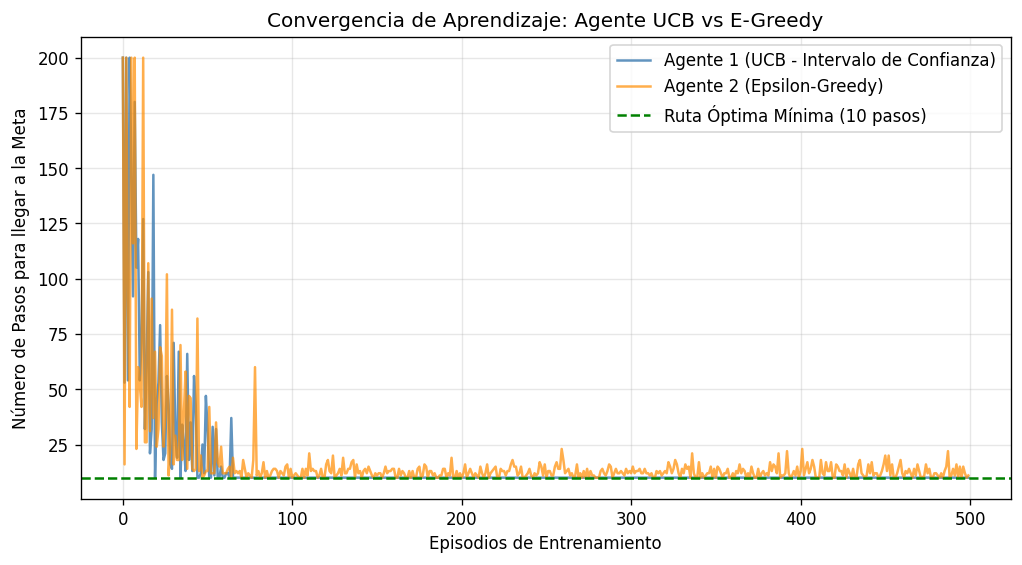

In [7]:
plt.figure(figsize=(10, 5), dpi=120)
plt.plot(history_ucb, label="Agente 1 (UCB - Intervalo de Confianza)", color="steelblue", alpha=0.85)
plt.plot(history_egreedy, label="Agente 2 (Epsilon-Greedy)", color="darkorange", alpha=0.7)
plt.axhline(y=10, color="green", linestyle="--", label="Ruta Óptima Mínima (10 pasos)")
plt.title("Convergencia de Aprendizaje: Agente UCB vs E-Greedy")
plt.xlabel("Episodios de Entrenamiento")
plt.ylabel("Número de Pasos para llegar a la Meta")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [8]:
def simular_carrera_visual(env, agent_ucb, agent_egreedy):
    print(" Empieza la carrera")
    print("Agente 1 (A1): UCB (Exploración Sistemática)")
    print("Agente 2 (A2): Epsilon-Greedy (Búsqueda Aleatoria)")
    print("S: Inicio | G: Meta | ██: Paredes / Barreras")
    
    pos_ucb = env.start
    pos_egreedy = env.start
    
    env.render(pos_ucb, pos_egreedy)
    
    done_ucb = False
    done_egreedy = False
    
    steps = 0
    
    while (not done_ucb or not done_egreedy) and steps < 20:
        steps += 1
        print(f"\n--- PASO {steps} ---")
        
        # Turno Agente 1 (UCB) - Modo explotación pura
        if not done_ucb:
            action_ucb = agent_ucb.choose_action(pos_ucb, env.actions, 1000)
            # Para explotación pura elegimos el argmax de Q
            best_action = None
            max_q = -1e9
            for a in env.actions:
                if agent_ucb.get_Q(pos_ucb, a) > max_q:
                    max_q = agent_ucb.get_Q(pos_ucb, a)
                    best_action = a
            next_pos, _, reached = env.step(pos_ucb, best_action)
            pos_ucb = next_pos
            if reached:
                done_ucb = True
                print("Agente 1 ha llegado a la meta")
                
        # Turno Agente 2 (E-Greedy) - Modo explotación pura
        if not done_egreedy:
            best_action_eg = None
            max_q_eg = -1e9
            for a in env.actions:
                if agent_egreedy.get_Q(pos_egreedy, a) > max_q_eg:
                    max_q_eg = agent_egreedy.get_Q(pos_egreedy, a)
                    best_action_eg = a
            next_pos_eg, _, reached_eg = env.step(pos_egreedy, best_action_eg)
            pos_egreedy = next_pos_eg
            if reached_eg:
                done_egreedy = True
                print("Agente 2 ha llegado a la meta")
                
        env.render(pos_ucb, pos_egreedy)
        
        if done_ucb and done_egreedy:
            break
            
    print(f"\nLa carrera terminó en {steps} pasos.")
    if done_ucb and (not done_egreedy or history_ucb[-1] < history_egreedy[-1]):
        print("GANADOR: Agente 1")
    elif done_egreedy:
        print("GANADOR: Agente 2")
    else:
        print("Ninguno logró terminar a tiempo")

# Simulamos una carrera
simular_carrera_visual(env, agent_ucb, agent_egreedy)


 Empieza la carrera
Agente 1 (A1): UCB (Exploración Sistemática)
Agente 2 (A2): Epsilon-Greedy (Búsqueda Aleatoria)
S: Inicio | G: Meta | ██: Paredes / Barreras

  -------------------------
 | 12 | . | . | . | . | . | 
  -------------------------
 | . | . | ██ | . | . | . | 
  -------------------------
 | . | . | ██ | . | . | . | 
  -------------------------
 | . | . | ██ | . | ██ | . | 
  -------------------------
 | . | . | ██ | . | ██ | . | 
  -------------------------
 | . | . | . | . | ██ | G | 
  -------------------------

--- PASO 1 ---

  -------------------------
 | S | 12 | . | . | . | . | 
  -------------------------
 | . | . | ██ | . | . | . | 
  -------------------------
 | . | . | ██ | . | . | . | 
  -------------------------
 | . | . | ██ | . | ██ | . | 
  -------------------------
 | . | . | ██ | . | ██ | . | 
  -------------------------
 | . | . | . | . | ██ | G | 
  -------------------------

--- PASO 2 ---

  -------------------------
 | S | . | 12 | . | . | . | 
  -

C:\Users\Natalia\AppData\Local\Temp\ipykernel_20832\1413546631.py:49: DeprecationWarning: `np.chararray` is deprecated and will be removed from the main namespace in the future. Use an array with a string or bytes dtype instead.
  grid = np.chararray((self.size, self.size), itemsize=3, unicode=True)


Analisis y Conclusión: Descubrimiento de Atajos y Rutas Rápidas

¿Cómo descubre atajos nuestro agente inteligente (Agente 1 - UCB)?

El problema de la exploración ciega ($\epsilon$-greedy):

  El Agente 2 utiliza una exploración aleatoria ciega. Aunque eventualmente podría cruzar la barrera de manera fortuita, gasta demasiados episodios chocando y dando vueltas sin sentido. Su convergencia es mucho más lenta y ruidosa, lo que significa que a menudo se queda estancado en la "ruta larga" y ancha, ya que es más fácil de transitar aleatoriamente.

La ventaja de UCB (Selección de acciones con intervalo de confianza):

  El Agente 1 (nuestro agente) utiliza UCB. En lugar de explorar al azar, lleva un registro exacto de cuántas veces ha estado en cada casilla ($N(s)$) y cuántas veces ha intentado cada acción ($N(s, a)$). 
  
  -Si una acción específica en un estado particular no ha sido probada mucho, el término de bonificación por incertidumbre $c \sqrt{\frac{\ln N(s)}{N(s, a)}}$ se vuelve sumamente alto.

  -Esto crea una "curiosidad matemática" que empuja al agente a probar movimientos poco explorados en zonas estrechas.

  -Gracias a esta curiosidad sistemática, nuestro agente descubre el estrecho paso en la barrera (el atajo) mucho más rápido que el competidor y aprende de manera robusta y constante a explotarlo, logrando completar el laberinto en solo 10 pasos de manera definitiva, ganando la carrera con holgura.
